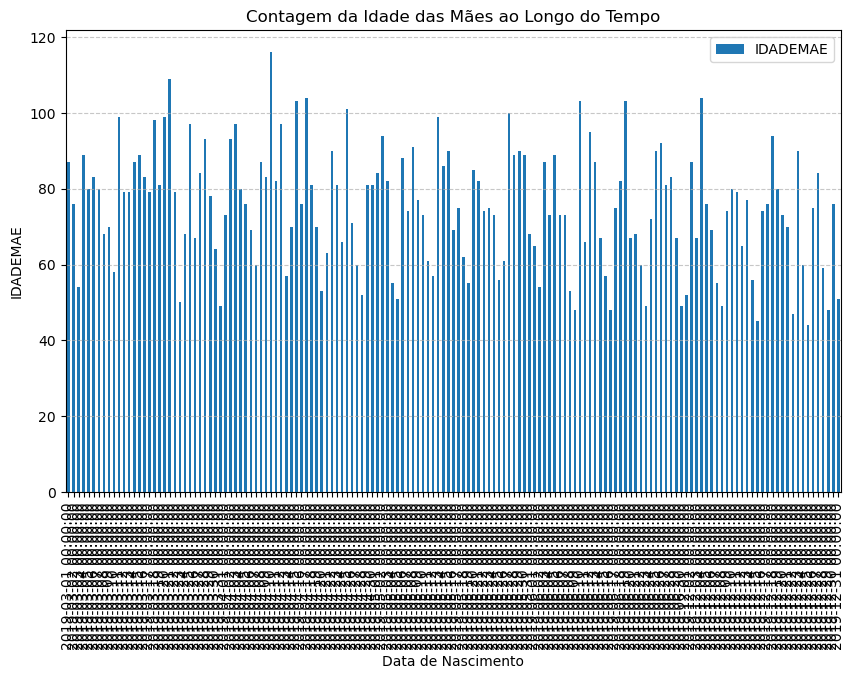

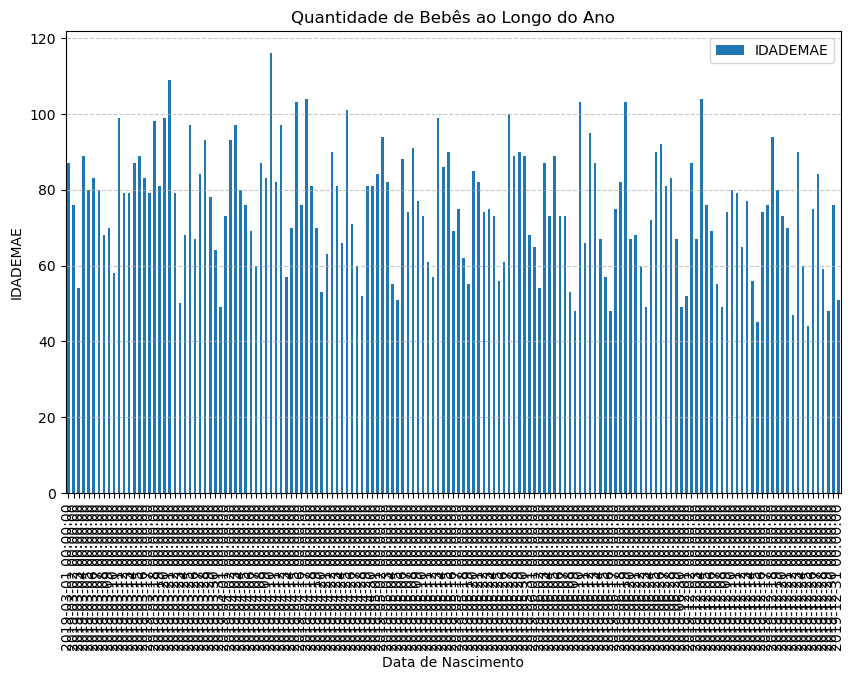

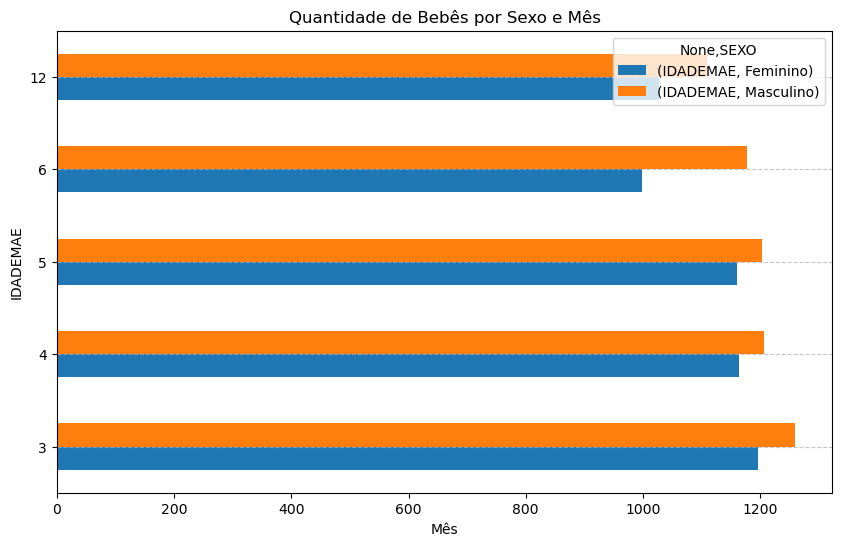

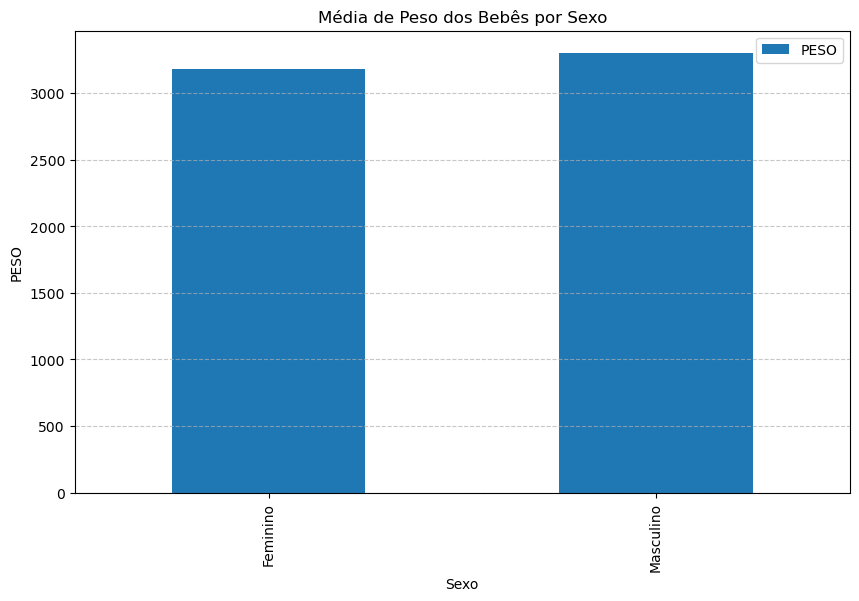

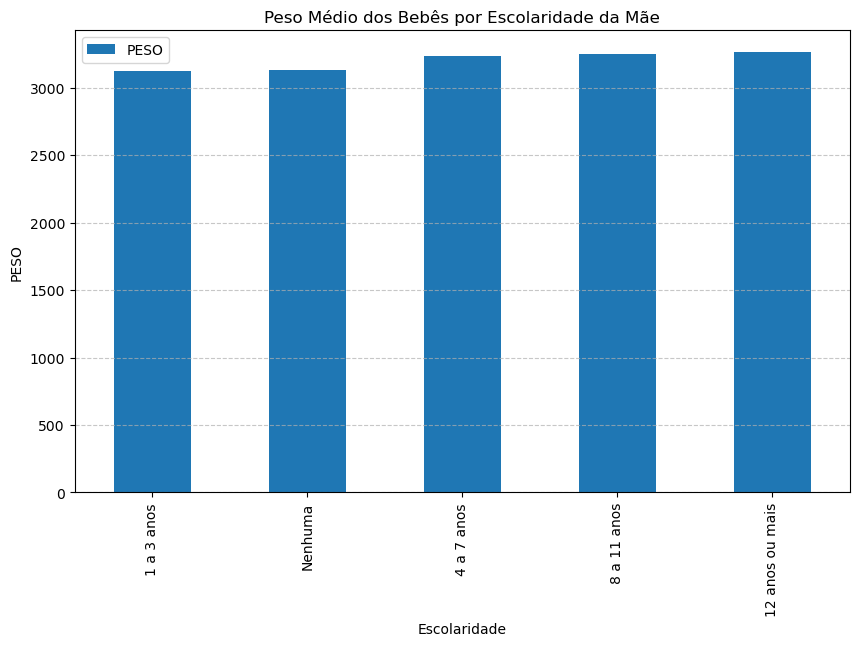

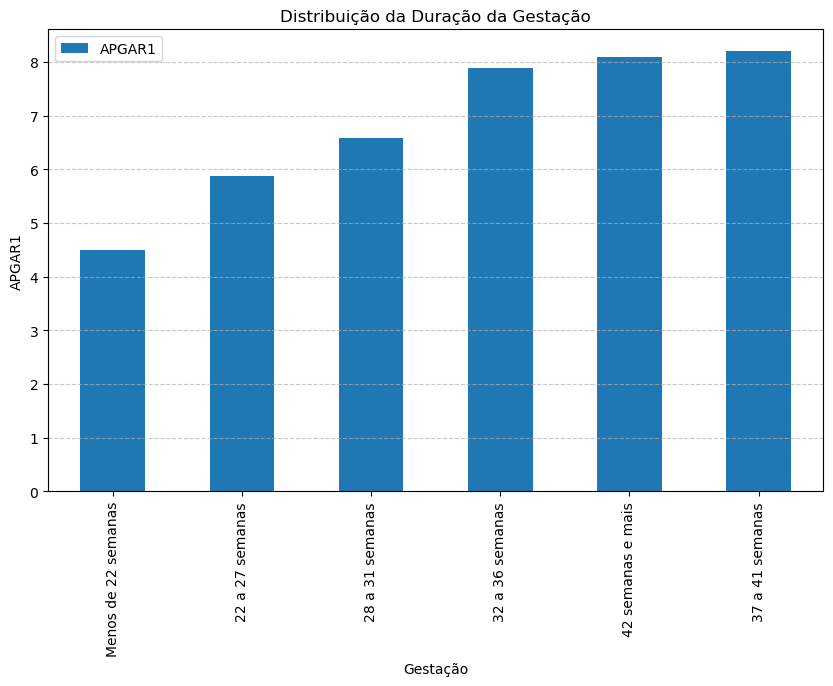

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Carregar a base de dados
file_path = 'C:/Users/fabio/Documents/EBAC/Modulo14/input/SINASC_RO_2019.csv' 
sinasc_data = pd.read_csv(file_path)

# Converter a coluna 'DTNASC' para datetime
sinasc_data['DTNASC'] = pd.to_datetime(sinasc_data['DTNASC'], errors='coerce')

# Adicionar a coluna 'MES' com os meses extraídos
sinasc_data['MES'] = sinasc_data['DTNASC'].dt.month

# Filtrar para os meses de interesse
meses_interesse = [3, 4, 5, 6, 12]
dados_filtrados = sinasc_data[sinasc_data['MES'].isin(meses_interesse)]

# Função para plotar gráficos com pivot table
def plota_pivot_table(data, values, index, aggfunc, title, xlabel, unstack=False, sort=False):
    pivot = data.pivot_table(values=values, index=index, aggfunc=aggfunc)
    if unstack:
        pivot = pivot.unstack()
    if sort:
        pivot = pivot.sort_values(by=values if not unstack else list(pivot.columns), ascending=True)
    
    pivot.plot(kind='bar' if not unstack else 'barh', figsize=(10, 6))
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(values)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Diretório para salvar os gráficos
output_dir = 'C:/Users/fabio/Documents/EBAC/Modulo14/save/figs'
os.makedirs(output_dir, exist_ok=True)

# Gráficos solicitados
# 1. Contagem da IDADEMAE x Tempo
plota_pivot_table(dados_filtrados, 'IDADEMAE', 'DTNASC', 'count', 'Contagem da Idade das Mães ao Longo do Tempo', 'Data de Nascimento')

# 2. Quantidade de bebês ao longo do ano
plota_pivot_table(dados_filtrados, 'IDADEMAE', 'DTNASC', 'count', 'Quantidade de Bebês ao Longo do Ano', 'Data de Nascimento')

# 3. Quantidade de bebês fem e masc por mês
plota_pivot_table(dados_filtrados, 'IDADEMAE', ['MES', 'SEXO'], 'count', 'Quantidade de Bebês por Sexo e Mês', 'Mês', unstack=True)

# 4. Média de peso dos bebês fem e masc
plota_pivot_table(dados_filtrados, 'PESO', 'SEXO', 'mean', 'Média de Peso dos Bebês por Sexo', 'Sexo')

# 5. Peso x Escolaridade mãe (ESCMAE)
plota_pivot_table(dados_filtrados, 'PESO', 'ESCMAE', 'mean', 'Peso Médio dos Bebês por Escolaridade da Mãe', 'Escolaridade', sort=True)

# 6. Distribuição da Duração da Gestação
plota_pivot_table(dados_filtrados, 'APGAR1', 'GESTACAO', 'mean', 'Distribuição da Duração da Gestação', 'Gestação', sort=True)


Para automatizar a geração de gráficos e facilitar o trabalho no futuro, eu criaria uma função genérica que faz todo o processo: filtra os dados, agrega os valores e gera os gráficos. Nessa função, eu incluiria parâmetros como meses, anos, colunas para análise e o tipo de agregação que quero aplicar. Isso evitaria repetir código sempre que precisar de um gráfico novo.

Além disso, eu usaria um arquivo de configuração, como um JSON ou YAML, onde eu definiria todas as informações para cada gráfico: quais dados usar, os meses ou anos de interesse, as métricas, e o tipo de gráfico. Assim, bastaria ajustar esse arquivo quando precisar de algo diferente, sem alterar o código diretamente.

Por fim, eu escreveria um loop no meu script para ler esse arquivo de configuração e gerar os gráficos automaticamente. Isso deixaria tudo mais escalável e eficiente, permitindo que eu trabalhasse em novos períodos ou métricas de forma muito mais simples.